In [ ]:
# importando bibliotecas

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [ ]:
# importando o arquivo e criando Dataframe
cars = pd.read_csv('arquivos/car_price_dataset.csv')
cars

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867
...,...,...,...,...,...,...,...,...,...,...
9995,Kia,Optima,2004,3.7,Diesel,Semi-Automatic,5794,2,4,8884
9996,Chevrolet,Impala,2002,1.4,Electric,Automatic,168000,2,1,6240
9997,BMW,3 Series,2010,3.0,Petrol,Automatic,86664,5,1,9866
9998,Ford,Explorer,2002,1.4,Hybrid,Automatic,225772,4,1,4084


In [ ]:
# conhecendo os dados
print('--- Informações Gerais ---')
cars.info()

print('\n---- Valores Nulos ----')
print(cars.isnull().sum())

print('\n ---- Dados Estatísticos ----')
cars.describe()

--- Informações Gerais ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         10000 non-null  object 
 1   Model         10000 non-null  object 
 2   Year          10000 non-null  int64  
 3   Engine_Size   10000 non-null  float64
 4   Fuel_Type     10000 non-null  object 
 5   Transmission  10000 non-null  object 
 6   Mileage       10000 non-null  int64  
 7   Doors         10000 non-null  int64  
 8   Owner_Count   10000 non-null  int64  
 9   Price         10000 non-null  int64  
dtypes: float64(1), int64(5), object(4)
memory usage: 781.4+ KB

---- Valores Nulos ----
Brand           0
Model           0
Year            0
Engine_Size     0
Fuel_Type       0
Transmission    0
Mileage         0
Doors           0
Owner_Count     0
Price           0
dtype: int64

 ---- Dados Estatísticos ----


,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,2011.543700,3.000560,149239.111800,3.497100,2.991100,8852.96440
std,6.897699,1.149324,86322.348957,1.110097,1.422682,3112.59681
min,2000.000000,1.000000,25.000000,2.000000,1.000000,2000.00000
25%,2006.000000,2.000000,74649.250000,3.000000,2.000000,6646.00000
50%,2012.000000,3.000000,149587.000000,3.000000,3.000000,8858.50000
75%,2017.000000,4.000000,223577.500000,4.000000,4.000000,11086.50000
max,2023.000000,5.000000,299947.000000,5.000000,5.000000,18301.00000


In [ ]:

preco_medio = np.mean(cars['Price'])
preco_mediano = np.median(cars['Price'])
maior_preco = np.max(cars['Price'])
menor_preco = np.min(cars['Price'])


print(f' O preço médio dos carros foi: {preco_medio}')
print(f' O preço mediano dos carros foi: {preco_mediano}')
print(f' O maior preço {maior_preco}')
print(f' O menor preço {menor_preco}')

 O preço médio dos carros foi: 8852.9644
 O preço mediano dos carros foi: 8858.5
 O maior preço 18301
 O menor preço 2000


Text(0, 0.5, 'Quantidade')

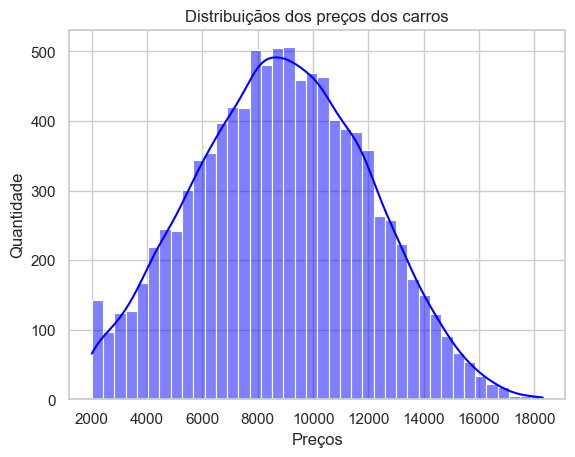

In [ ]:
# como os dados estão distribuidos
sns.histplot(cars['Price'], kde=True, color='blue')
plt.title("Distribuiçãos dos preços dos carros")
plt.xlabel('Preços')
plt.ylabel("Quantidade")

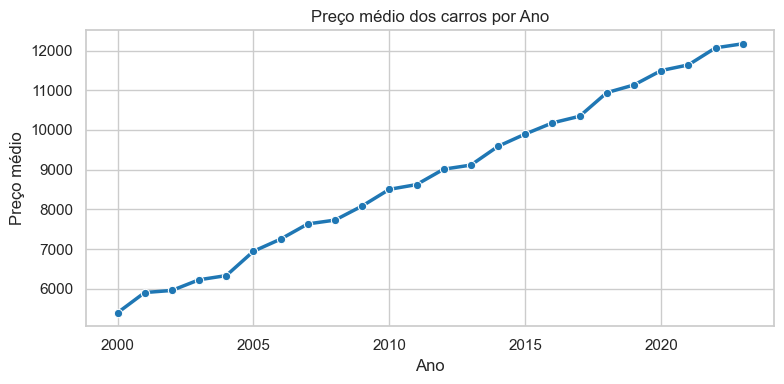

In [ ]:
# relação do ano de fabricação com o preço
plt.figure(figsize= (8, 4))
ano_preco = cars.groupby('Year')['Price'].mean().reset_index()
sns.lineplot(
    data=ano_preco, 
    x='Year', 
    y='Price', 
    marker='o',           
    linewidth=2.5,      
    color='#1f77b4',     
)
plt.title("Preço médio dos carros por Ano")
plt.xlabel("Ano")
plt.ylabel("Preço médio")
plt.tight_layout()
plt.show()


C:\Users\vini7\AppData\Local\Temp\ipykernel_24656\1141855370.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


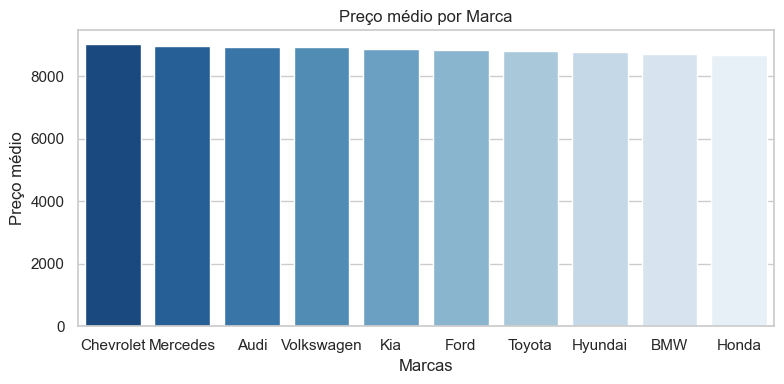

In [ ]:
# relação da marca com o preço
plt.figure(figsize= (8, 4))
ordem_marcas = cars.groupby('Brand')['Price'].mean().sort_values(ascending=False).index

sns.barplot(
    data=cars, 
    x='Brand', 
    y='Price', 
    order=ordem_marcas, 
    palette='Blues_r',    
    errorbar=None,                 
)
plt.title("Preço médio por Marca")
plt.xlabel("Marcas")
plt.ylabel("Preço médio")
plt.tight_layout()
plt.show()


C:\Users\vini7\AppData\Local\Temp\ipykernel_24656\970864896.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= cars,


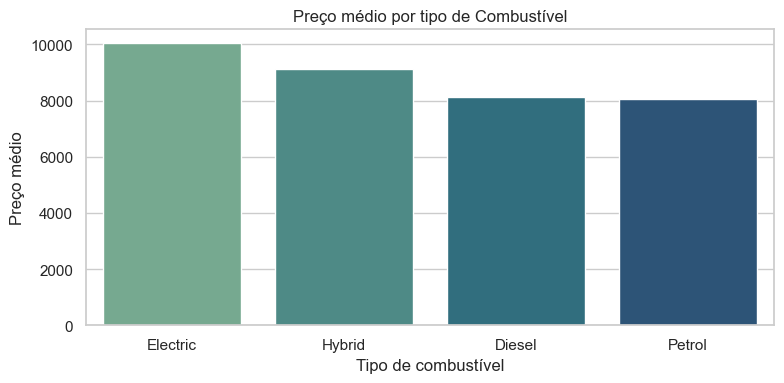

In [ ]:
# relação do tipo de combustível que o carro usa com o preço
plt.figure(figsize=(8,4))

ordem_combustivel = cars.groupby('Fuel_Type')['Price'].mean().sort_values(ascending=False).index
sns.barplot(data= cars,
             x= 'Fuel_Type', 
             y = 'Price', order = ordem_combustivel, 
             palette='crest', 
             errorbar=None
             )

plt.title("Preço médio por tipo de Combustível")
plt.xlabel("Tipo de combustível")
plt.ylabel("Preço médio")
plt.tight_layout()
plt.show()


C:\Users\vini7\AppData\Local\Temp\ipykernel_24656\118467371.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data= cars,


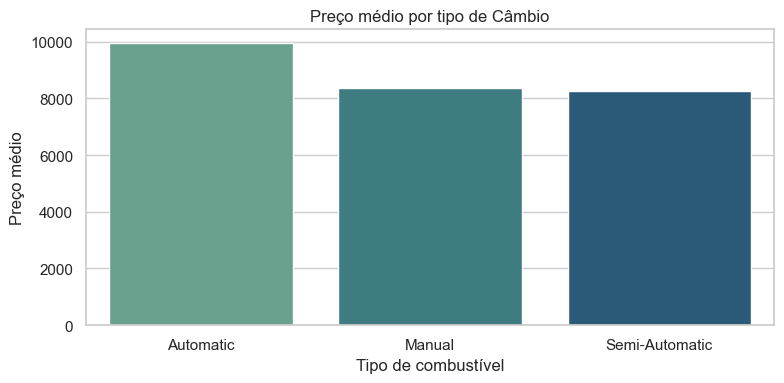

In [ ]:
# relação do tipo de câmbio com o preço
ordem_cambio = cars.groupby('Transmission')['Price'].mean().sort_values(ascending=False).index

plt.figure(figsize=(8,4))
sns.barplot(data= cars,
             x = 'Transmission', 
             y = 'Price', 
             order = ordem_cambio, 
             palette='crest', 
             errorbar = None)

plt.title("Preço médio por tipo de Câmbio")
plt.xlabel("Tipo de combustível")
plt.ylabel("Preço médio")
plt.tight_layout()
plt.show()

In [ ]:
# criando as variaveis para o modelo
X = cars.drop(columns=['Price'])
y = cars['Price']

In [204]:
colunas_categoricas = ['Brand', 'Model', 'Fuel_Type', 'Transmission']
colunas_numericas = ['Year', 'Engine_Size',  'Mileage', 'Doors', 'Owner_Count']

In [ ]:
# transformando colunas categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', colunas_numericas),
        ('cat', OneHotEncoder(handle_unknown='ignore'), colunas_categoricas)
    ]
)

X_processado = preprocessor.fit_transform(X)

In [ ]:
# separando dados de treino e dados de teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X_processado, y, test_size= 0.2, random_state= 42)

In [ ]:
# treinamneto do modelo de ramdom forest
random_forest_model = RandomForestRegressor(random_state=42)
random_forest_model.fit(X_treino, y_treino)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [ ]:
# previsoes com modelo de random forest
previsoes = random_forest_model.predict(X_teste)

In [ ]:
# treinamento e previsões com regressão linear
linear_regression_model = LinearRegression()
linear_regression_model.fit(X_treino, y_treino)
previsoes2 = linear_regression_model.predict(X_teste)

In [ ]:
# aplicação das métricas
erro_medio1 = mean_absolute_error(y_teste, previsoes)
erro_medio2 = mean_absolute_error(y_teste, previsoes2)

score1 = r2_score(y_teste, previsoes)
score2 = r2_score(y_teste, previsoes2)

In [ ]:
# resultados: 
print(" ---- Avaliação de Modelos ----")

print('Random Forest')
print(f'Erro Médio Absoluto: R${erro_medio1:.2f}')
print(f'Score R²: {score1:.2f}')

print('\n')
print('Regressão Linear')
print(f'Erro Médio Absoluto: R${erro_medio2:.2f}')
print(f'Score R²: {score2:.2f}')

 ---- Avaliação de Modelos ----
Random Forest
Erro Médio Absoluto: R$260.73
Score R²: 0.99


Regressão Linear
Erro Médio Absoluto: R$135.49
Score R²: 1.00
